In [58]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'income_tax_collection',
    persist_directory = './income_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [59]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str
    
graph_builder = StateGraph(AgentState)

In [60]:
def retrieve(state: AgentState) -> AgentState:
    query = state['query']  
    docs = retriever.invoke(query)  
    return {'context': docs}  

In [61]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [62]:
from langchain_classic import hub

generate_prompt = hub.pull("rlm/rag-prompt")

def generate(state: AgentState) -> AgentState:
    
    context = state['context']  
    query = state['query']      

    rag_chain = generate_prompt | llm
    
    response = rag_chain.invoke({'question': query, 'context': context})
    
    return {'answer': response}  

In [63]:
from langchain_classic import hub
from typing import Literal

doc_relevance_prompt = hub.pull("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['generate', 'rewrite']:
    query = state['query']  
    context = state['context']  

    print(f'context == {context}')

    doc_relevance_chain = doc_relevance_prompt | llm
    
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})

    print(f'doc relevance response: {response}')
    
    if response['Score'] == 1:
        return 'generate'
    
    return 'rewrite'

In [64]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(f"""
사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요 
사전: {dictionary}                                           
질문: {{query}}
""")

def rewrite(state: AgentState) -> AgentState:
    
    query = state['query']  
    
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    response = rewrite_chain.invoke({'query': query})
    
    return {'query': response}  

In [65]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

In [66]:
from langgraph.graph import START, END

graph_builder.add_edge(START,'retrieve')
graph_builder.add_conditional_edges('retrieve',check_doc_relevance)
graph_builder.add_edge('rewrite','retrieve')
graph_builder.add_edge('generate', END)


In [67]:
graph = graph_builder.compile()

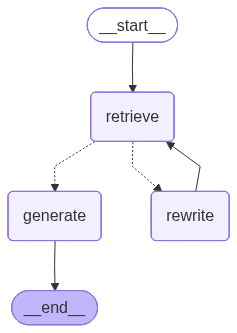

In [68]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [69]:
initial_state = {'query': '연봉 5천만원 세금'}
graph.invoke(initial_state)

context == [Document(id='ea6177bb-5a20-4d60-9951-c7a878fecec7', metadata={'source': './documents/income_tax.md'}, page_content='10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. <대통령 2014. 12. 23.> <전문개정 2009. 12. 31.>\n\n제64조(부동산매매업자에 대한 세액 계산의 특례)\n\n1) 대통령령으로 정하는 부동산매매업(이하 “부동산매매업”이라 한다)을 영위하는 거주자가 이하 “부동산매매업자”라 한다)로서 종합소득세법에 제104조제1항제1호(본항을 포함한다) 및 제103조 또는 같은 조 제7항 각 호의 어느 하나에 해당하는 자산의 매매자익(이하 “주택등매매차익”이라 한다)이 있는 자의 종합소득 산출세액은 다음 각 호의 세액 중 많은 것으로 한다. <개정 2014. 12. 23., 2017. 12. 19., 2020. 12. 29.>\n\n1. 종합소득 산출세액\n\n다음 각 목에 따른 세액의 합계액 가. 주택등매매차익에 따른 세율을 적용하여 산출한 세액의 합계액 나. 종합소득세법 제55조에 따라 주택등매매차익에 대한 개별세액을 공제한 금액을 과세표준으로 하고 이에 제55조에 따른 세율을 적용하여 산출세액\n\n② 부동산매매업자에 대한 주택등매매차익의 계산과 그 밖에 종합소득 산출세액의 계산에 필요한 사항은 대통령령으로 정한다. <전문개정 2009. 12. 31.>\n\n제64조의2(주택임대소득에 대한 세액 계산의 특례)\n\n다음 각 호의 세액 중 하나를 선택하여 적용한다. 1. 제104조제1항제7호를 적용하지 아니하는 종합소득 세액 계산의 특례 2. 다음 각 목의 세액에 대한 계산 가. 분리과세 주택임대소득에 대한 사

{'query': '연봉 5천만원 세금',
 'context': [Document(id='ea6177bb-5a20-4d60-9951-c7a878fecec7', metadata={'source': './documents/income_tax.md'}, page_content='10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. <대통령 2014. 12. 23.> <전문개정 2009. 12. 31.>\n\n제64조(부동산매매업자에 대한 세액 계산의 특례)\n\n1) 대통령령으로 정하는 부동산매매업(이하 “부동산매매업”이라 한다)을 영위하는 거주자가 이하 “부동산매매업자”라 한다)로서 종합소득세법에 제104조제1항제1호(본항을 포함한다) 및 제103조 또는 같은 조 제7항 각 호의 어느 하나에 해당하는 자산의 매매자익(이하 “주택등매매차익”이라 한다)이 있는 자의 종합소득 산출세액은 다음 각 호의 세액 중 많은 것으로 한다. <개정 2014. 12. 23., 2017. 12. 19., 2020. 12. 29.>\n\n1. 종합소득 산출세액\n\n다음 각 목에 따른 세액의 합계액 가. 주택등매매차익에 따른 세율을 적용하여 산출한 세액의 합계액 나. 종합소득세법 제55조에 따라 주택등매매차익에 대한 개별세액을 공제한 금액을 과세표준으로 하고 이에 제55조에 따른 세율을 적용하여 산출세액\n\n② 부동산매매업자에 대한 주택등매매차익의 계산과 그 밖에 종합소득 산출세액의 계산에 필요한 사항은 대통령령으로 정한다. <전문개정 2009. 12. 31.>\n\n제64조의2(주택임대소득에 대한 세액 계산의 특례)\n\n다음 각 호의 세액 중 하나를 선택하여 적용한다. 1. 제104조제1항제7호를 적용하지 아니하는 종합소득 세액 계산의 특례 2. 다음 각 목의 세액에 대